<a href="https://colab.research.google.com/github/charand0123/cv-lab6/blob/main/CV_LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

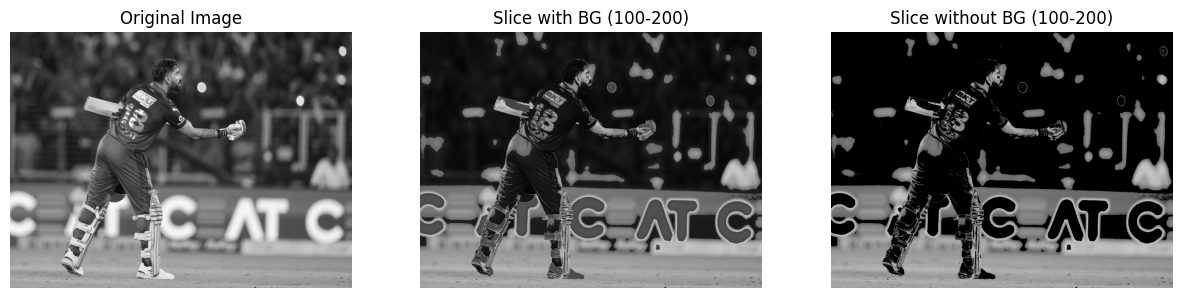

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

r_min = 100
r_max = 200

img = cv2.imread("/content/goat.jpg",0)

# Initialize slice_with_bg and slice_without_bg
slice_with_bg = img.copy()
slice_without_bg = np.zeros(img.shape, dtype=np.uint8)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        pixel_value = img[i, j]
        # Calculate the average intensity for the comparison to resolve the ValueError
        avg_intensity = np.mean(pixel_value)

        if r_min <= avg_intensity <= r_max:
            # Keep the original pixel value for both slices if its average intensity is within the range
            slice_with_bg[i, j] = pixel_value
            slice_without_bg[i, j] = pixel_value
        else:
            # For slice_with_bg, dim the background pixels (outside the range)
            slice_with_bg[i, j] = img[i, j] // 3
            slice_without_bg[i, j] = 0

# Display images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
# Convert from BGR to RGB for correct display with matplotlib
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
# Convert from BGR to RGB for correct display with matplotlib
plt.imshow(cv2.cvtColor(slice_with_bg, cv2.COLOR_BGR2RGB))
plt.title(f'Slice with BG ({r_min}-{r_max})')
plt.axis('off')

plt.subplot(1, 3, 3)
# Convert from BGR to RGB for correct display with matplotlib
plt.imshow(cv2.cvtColor(slice_without_bg, cv2.COLOR_BGR2RGB))
plt.title(f'Slice without BG ({r_min}-{r_max})')
plt.axis('off')

plt.show()